In [39]:
from scripts.synthetic_gap import *
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator

from scripts.gap_sampler import sample_gaps

from scripts.score_method import score_method

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# **Random Sampler**

In [40]:
# --- draw a random sample of synthetic SWC gaps across all stations ---

# ------------------------- knobs -------------------------
DATA_DIR = "prewashed_data"   # path to the prewashed station csvs
N_GAPS  = 500    # how many synthetic gaps to draw
SEED    = 8      # master seed, for a reproducible sample

COLUMN  = ["SWC_5", "SWC_10", "SWC_20", "SWC_50"]   # soil moisture only, for now.
                      # (None now means ANY measurement column — Ppt and T_* too —
                      # so we pin the SWC menu; "SWC_50" would fix one depth)

LENGTHS = ["6h","12h","18h","23h"]    # the exact gap lengths to draw;
                  # None -> draw lengths that match the DURATIONS of real gaps in
                  # the data (durations only — every sampled gap is synthetic,
                  # punched into a fully clean stretch)

STRATA  = True    # True -> split N_GAPS evenly across the distinct lengths;
                  # False -> draw each gap's length from the pool at random

RAIN_FRAC = 0     # None -> don't control rain; or a fraction like 0.5 -> that share
                  # of gaps must contain rain, enforced at every distinct gap length

CONTEXT = "1h"   # data kept on each side of each gap

POOL_MAX = "24h"  # with LENGTHS=None, only durations shorter than this are matched

MET = False       # False -> soil stations; True -> the *_met stations
# ----------------------------------------------------------

samples = sample_gaps(DATA_DIR, n_gaps=N_GAPS, seed=SEED, column=COLUMN,
                      lengths=LENGTHS, strata=STRATA, rain_frac=RAIN_FRAC,
                      context=CONTEXT, pool_max=POOL_MAX, met=MET)

500 gaps drawn (612 attempts)
rain      False
length_h       
6           125
12          125
18          125
23          125


In [41]:
samples[:10]   # show the first 10 rows of the sample table

[{'station': 'FD17',
  'column': 'SWC_10',
  'length_h': 6,
  'start': Timestamp('2020-11-24 23:00:00'),
  'rain_in_gap': False,
  'gapped':                      Ppt  SWC_5  SWC_10  SWC_20  SWC_50    T_5   T_10   T_20  \
  Date                                                                           
  2020-11-24 22:00:00  0.0  0.121   0.134   0.128   0.125  19.78  20.24  20.71   
  2020-11-24 23:00:00  0.0  0.121     NaN   0.128   0.125  19.66  20.08  20.61   
  2020-11-25 00:00:00  0.0  0.121     NaN   0.128   0.125  19.72  20.00  20.52   
  2020-11-25 01:00:00  0.0  0.121     NaN   0.128   0.125  19.43  19.90  20.45   
  2020-11-25 02:00:00  0.0  0.121     NaN   0.128   0.125  19.07  19.71  20.37   
  2020-11-25 03:00:00  0.0  0.120     NaN   0.128   0.126  18.65  19.47  20.27   
  2020-11-25 04:00:00  0.0  0.120     NaN   0.128   0.126  18.35  19.21  20.14   
  2020-11-25 05:00:00  0.0  0.120   0.133   0.128   0.126  18.16  19.01  19.99   
  
                        T_50    Flag  

# **Imputation methods**

**A general imputation method `impute(gapped, column)`:**

`score_method` runs, for every sample `s` in `samples`:

```python
est   = impute(s["gapped"], s["column"]).loc[s["answer"].index]
truth = s["answer"][s["column"]]
err   = est - truth
```

**You receive, per call:**

- `gapped` — a `pd.DataFrame` with an hourly `DatetimeIndex` named `Date`, spanning the gap plus `CONTEXT` rows on each side. `gapped[column]` contains exactly one run of `length_h` consecutive `NaN`s (the synthetic gap) and real values everywhere else. Every other column is complete — no other `NaN` exists anywhere in the frame.
- `column` — a `str`, the name of the gapped column (e.g. `"SWC_5"`).

**You must return:**

- a `pd.Series` with numeric values whose index contains every timestamp of the gap. `.loc[s["answer"].index]` is applied to it, so if even one gap timestamp is missing from your index the run stops with a `KeyError`. The simplest valid return is the full column with the hole filled — e.g. `gapped[column].interpolate(...)` or `.ffill()` — since those keep the whole `gapped.index`.
- values at non-gap timestamps are never read; only the gap rows are scored.

**How your fills are scored:** per gap, `err = fill − truth` at each gap timestamp, then `rmse = sqrt(mean(err²))`, `mae = mean(|err|)`, `bias = mean(err)` (positive bias = fill too wet). A `NaN` fill at a gap timestamp is silently skipped by those means, so the gap is scored on the subset you did fill — and if you fill nothing, the gap's metrics are `NaN`. Fill every gap row.

**Two rules:**

- Never modify `gapped` in place (no `inplace=True`, no assigning into its columns): every method cell scores the same `samples` objects, so an in-place fill hands your answers to the next method.
- The ground truth (`s["answer"]`) is never passed to you; use anything inside `gapped` — the other columns (`Ppt`, `T_*`, other depths) and all context rows are fair game.

**Scoring call:** `scores_x = score_method(impute_x, samples, name="candidate N — ...")` prints the report and returns the per-gap DataFrame; `name=None` scores silently.

In [ ]:
# --- (naive baseline): carry the last observation forward ---
def impute_locf(gapped, column):
    """Fill NaNs with the most recent value before the gap."""
    return gapped[column].ffill()

scores_locf = score_method(impute_locf, samples,
                           name="last observation carried forward")

candidate 2 — last observation carried forward, 500 gaps (m3/m3)
overall: RMSE 0.0026   MAE 0.0022   bias +0.0011
length_bin  rain_in_gap   n   rmse    mae   bias
        6h        False 125 0.0014 0.0012 0.0007
       12h        False 125 0.0020 0.0015 0.0007
       18h        False 125 0.0037 0.0032 0.0013
       23h        False 125 0.0033 0.0029 0.0019


In [ ]:
# --- (naive): nearest observation -- front half gets the value
# --- before the gap, back half gets the value after it
def impute_nearest(gapped, column):
    """Fill each NaN with whichever valid observation is closer in time."""
    s = gapped[column]
    t = s.index.to_series()
    t_prev = t.where(s.notna()).ffill()    # time of last value before each row
    t_next = t.where(s.notna()).bfill()    # time of next value after each row
    use_next = (t_next - t) < (t - t_prev) # strictly closer ahead -> take the end point
    return s.ffill().where(~use_next, s.bfill())

scores_nearest = score_method(impute_nearest, samples,
                              name="nearest observation")

candidate 3 — nearest observation, 500 gaps (m3/m3)
overall: RMSE 0.0018   MAE 0.0014   bias +0.0001
length_bin  rain_in_gap   n   rmse    mae   bias
        6h        False 125 0.0009 0.0007 0.0001
       12h        False 125 0.0016 0.0011 0.0001
       18h        False 125 0.0022 0.0017 0.0001
       23h        False 125 0.0024 0.0020 0.0002


In [ ]:
# --- time-aware linear interpolation ---
def impute_linear(gapped, column):
    """Fill NaNs in one column by linear interpolation against the time index."""
    return gapped[column].interpolate(method="time", limit_area="inside")

scores = score_method(impute_linear, samples,
                      name="linear interpolation")

candidate 1 — linear interpolation, 500 gaps (m3/m3)
overall: RMSE 0.0014   MAE 0.0011   bias +0.0001
length_bin  rain_in_gap   n   rmse    mae   bias
        6h        False 125 0.0005 0.0005 0.0001
       12h        False 125 0.0013 0.0009 0.0001
       18h        False 125 0.0017 0.0015 0.0001
       23h        False 125 0.0019 0.0016 0.0002


In [45]:
# --- PCHIP (shape-preserving cubic; follows curvature, never overshoots) ---
def impute_pchip(gapped, column):
    """Fill NaNs with monotone piecewise-cubic interpolation (scipy PCHIP via pandas)."""
    return gapped[column].interpolate(method="pchip", limit_area="inside")

scores_pchip = score_method(impute_pchip, samples,
                            name="PCHIP")

PCHIP, 500 gaps (m3/m3)
overall: RMSE 0.0014   MAE 0.0011   bias +0.0001
length_bin  rain_in_gap   n   rmse    mae   bias
        6h        False 125 0.0005 0.0005 0.0001
       12h        False 125 0.0013 0.0009 0.0001
       18h        False 125 0.0017 0.0015 0.0001
       23h        False 125 0.0019 0.0016 0.0002


In [46]:
def impute_akima(gapped, column):
    """Fill NaNs with Akima interpolation (scipy Akima1DInterpolator via pandas)."""
    return gapped[column].interpolate(method="akima", limit_area="inside")

scores_akima = score_method(impute_akima, samples,
                            name="Akima")

Akima, 500 gaps (m3/m3)
overall: RMSE 0.0014   MAE 0.0011   bias +0.0001
length_bin  rain_in_gap   n   rmse    mae   bias
        6h        False 125 0.0005 0.0005 0.0001
       12h        False 125 0.0013 0.0009 0.0001
       18h        False 125 0.0017 0.0015 0.0001
       23h        False 125 0.0019 0.0016 0.0002


# **Graphics**

In [48]:
METHODS = {"LOCF": impute_locf, "Nearest": impute_nearest,
           "Linear": impute_linear, "PCHIP": impute_pchip,
           "Akima": impute_akima
           }

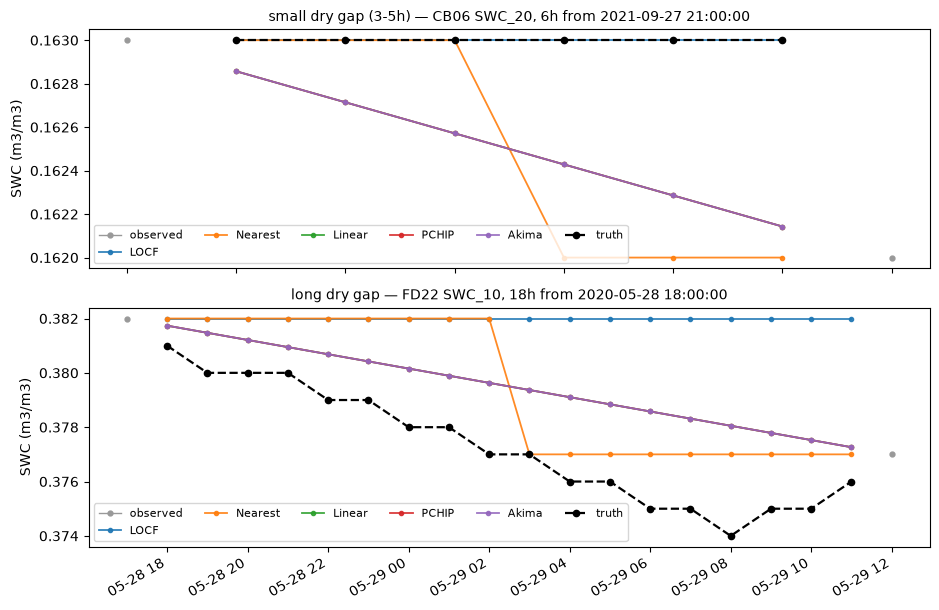

In [49]:
# --- demo: the four methods filling example gaps ---

_demo_rng = np.random.default_rng()      # unseeded -> a fresh random draw every run

def _pick(cond):
    """A randomly drawn sample index matching cond, else None."""
    hits = [i for i, s in enumerate(samples) if cond(s)]
    return int(_demo_rng.choice(hits)) if hits else None

examples = [
            ("small dry gap (3-5h)", _pick(lambda s: 3 < s["length_h"] <= 6 and not s["rain_in_gap"])),
            ("long dry gap",   _pick(lambda s: s["length_h"] >= 13 and not s["rain_in_gap"])),
            ("rain in gap",    _pick(lambda s: s["rain_in_gap"] and s["length_h"] >= 4))]
examples = [(t, i) for t, i in examples if i is not None]

fig, axes = plt.subplots(len(examples), 1, figsize=(9.5, 3.1 * len(examples)), squeeze=False)
for ax, (title, i) in zip(axes[:, 0], examples):
    s = samples[i]
    col, win = s["column"], s["answer"].index
    obs = s["gapped"][col]
    # shade rainy hours in the window
    for t in win[s["gapped"].loc[win, "Ppt"].fillna(0).gt(0)]:
        ax.axvspan(t - pd.Timedelta("30min"), t + pd.Timedelta("30min"),
                   color="tab:blue", alpha=0.10, lw=0)
    ax.plot(obs.index, obs, "o-", color="0.6", ms=3.5, lw=1, label="observed")
    for name, fn in METHODS.items():
        ax.plot(win, fn(s["gapped"], col).loc[win], "-o", ms=3, lw=1.3, alpha=0.9, label=name)
    ax.plot(win, s["answer"][col], "k--o", ms=4.5, lw=1.6, label="truth", zorder=5)
    ax.set_title(f"{title} — {s['station']} {col}, {s['length_h']}h from {win[0]}", fontsize=10)
    ax.set_ylabel("SWC (m3/m3)")
    ax.legend(ncols=6, fontsize=8, loc="best")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [50]:
order = ["LOCF", "Nearest", "Linear", "PCHIP", "Akima"]
all_scores = pd.concat([df.assign(method=m) for m, df in
                        [("LOCF", scores_locf), ("Nearest", scores_nearest),
                         ("Linear", scores), ("PCHIP", scores_pchip), ("Akima", scores_akima)]],
                       ignore_index=True)

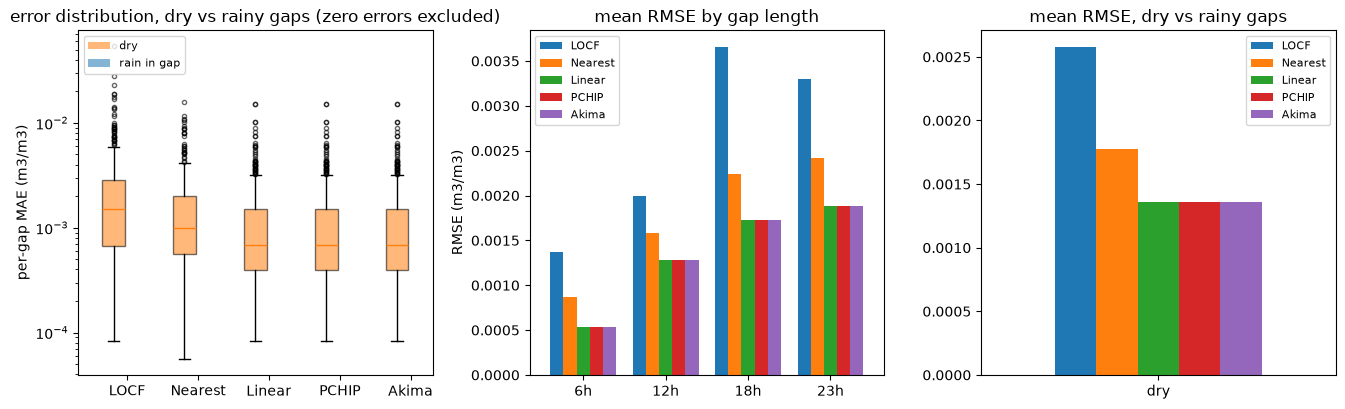

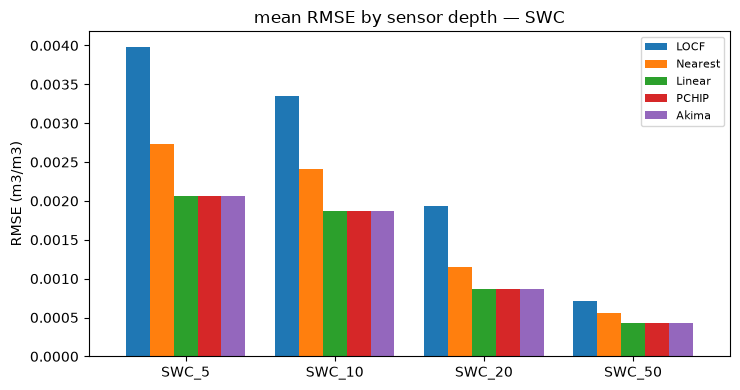

In [51]:
# --- error comparison across methods ---
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

# 1) per-gap MAE distributions, dry and rain-in-gap side by side
#    (log scale; zero-error gaps are excluded)
pos = np.arange(len(order))
groups = [("dry", ~all_scores["rain_in_gap"], "tab:orange", -0.19),
          ("rain in gap", all_scores["rain_in_gap"], "tab:blue", +0.19)]
for label, mask, color, off in groups:
    sub = all_scores[mask]
    if sub.empty:                       # e.g. RAIN_FRAC = 0 -> no rainy gaps drawn
        continue
    data = [sub.loc[(sub["method"] == m) & (sub["mae"] > 0), "mae"] for m in order]
    bp = axes[0].boxplot(data, positions=pos + off, widths=0.32, patch_artist=True,
                         flierprops=dict(markersize=3, alpha=0.6))
    for b in bp["boxes"]:
        b.set_facecolor(color)
        b.set_alpha(0.55)
axes[0].set_xticks(pos)
axes[0].set_xticklabels(order)
axes[0].set_yscale("log")
axes[0].set_ylabel("per-gap MAE (m3/m3)")
axes[0].set_title("error distribution, dry vs rainy gaps (zero errors excluded)")
axes[0].legend(handles=[Patch(facecolor=c, alpha=0.55, label=l) for l, _, c, _ in groups],
               fontsize=8, loc="upper left")

# 2) mean RMSE by gap length
(all_scores.pivot_table(index="length_bin", columns="method", values="rmse", observed=False)
           .loc[:, order]
           .plot.bar(ax=axes[1], rot=0, width=0.8))
axes[1].set_title("mean RMSE by gap length")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE (m3/m3)")
axes[1].legend(fontsize=8)

# 3) dry gaps vs rain-in-gap
piv = (all_scores.assign(rain=all_scores["rain_in_gap"].map({False: "dry", True: "rain in gap"}))
                 .pivot_table(index="rain", columns="method", values="rmse")
                 .loc[:, order])
piv.plot.bar(ax=axes[2], rot=0, width=0.7)
axes[2].set_title("mean RMSE, dry vs rainy gaps")
axes[2].set_xlabel("")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

# methods by sensor depth — one chart per data type (SWC, T, ...) that has
# gaps at more than one depth in this sample
depth_scores = all_scores[all_scores["column"].str.contains("_")]     # e.g. SWC_5, T_20
for prefix in sorted(depth_scores["column"].str.split("_").str[0].unique()):
    sub = depth_scores[depth_scores["column"].str.startswith(prefix + "_")]
    if sub["column"].nunique() < 2:
        continue                                    # only one depth -> nothing to compare
    depths = sorted(sub["column"].unique(), key=lambda c: int(c.split("_")[1]))
    fig2, ax = plt.subplots(figsize=(7.5, 4))
    (sub.pivot_table(index="column", columns="method", values="rmse")
        .loc[depths, order]
        .plot.bar(ax=ax, rot=0, width=0.8))
    ax.set_title(f"mean RMSE by sensor depth — {prefix}")
    ax.set_xlabel("")
    ax.set_ylabel("RMSE (m3/m3)")
    ax.legend(fontsize=8)
    fig2.tight_layout()
    plt.show()
